In [1]:
import xarray as xr
import numpy as np
from xgcm import Grid
import matplotlib.pyplot as plt
from fastjmd95 import rho

In [2]:
ds = xr.open_dataset('TS_timestep4500.nc')

In [3]:
div = grid.diff(ds.U.isel(k=0),'X') + grid.diff(ds.V.isel(k=0),'Y')


NameError: name 'grid' is not defined

In [7]:
slice1=np.zeros((51,100))
slice2=np.zeros((51,100))
slice3=np.zeros((100))
for i in range(0,100):
    slice1[:,i] = ds.Theta.isel(i=slice(0,200)).isel(j=slice(0,200))[:,199-i*2,i].values
    slice2[:,i] = ds.Salt.isel(i=slice(0,200)).isel(j=slice(0,200))[:,199-i*2,i].values
    #slice3[i] = div.isel(i=slice(0,200)).isel(j=slice(0,200))[199-i*2,i].values

In [8]:
pd0 = rho(slice2, slice1, 0.)

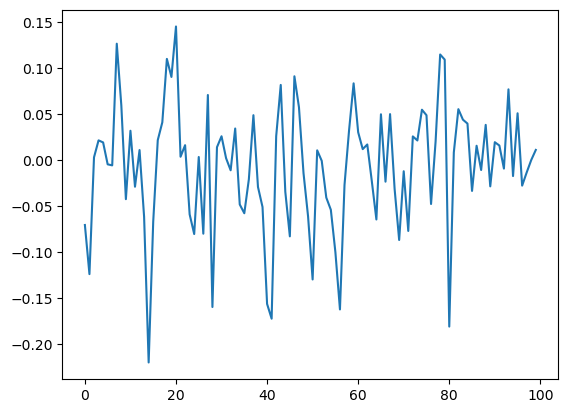

In [30]:
plt.plot(slice3)

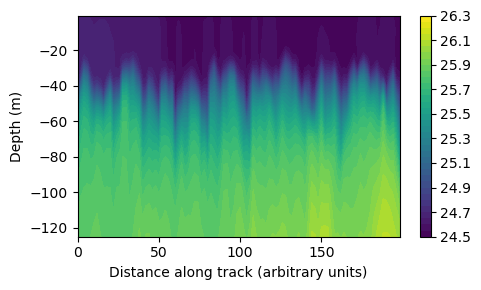

In [15]:
plt.figure(figsize=(5,3))
cs = plt.contourf(np.arange(0,200,2), ds.Z.values[0:24], pd0[0:24,:]-1000,levels=np.arange(24.5,26.3,0.05))
plt.colorbar(cs)
plt.xlabel('Distance along track (arbitrary units)')
plt.ylabel('Depth (m)')
plt.tight_layout()
plt.savefig('slice_density.png')

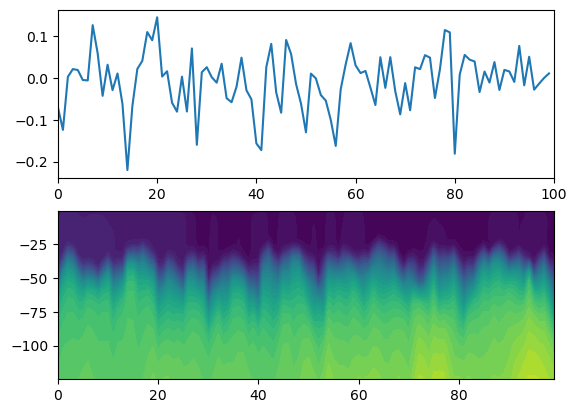

In [59]:
plt.subplot(211)
plt.plot(slice3)
#plt.axvline(14,color='r')
#plt.axvline(41,color='r')
plt.xlim(0,100)

plt.subplot(212)
cs = plt.contourf(np.arange(0,100), ds.Z.values[0:24], pd0[0:24,:]-1000,levels=np.arange(24.5,26.3,0.05))
#plt.colorbar(cs)
#plt.axvline(14,color='r')
#plt.axvline(41,color='r')

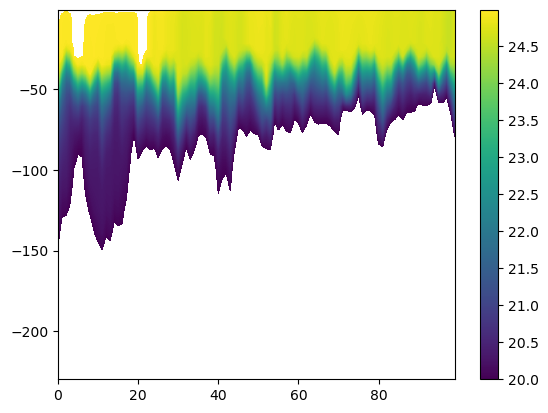

In [25]:
cs = plt.contourf(np.arange(0,100), ds.Z.values[0:30], slice1[0:30,:],levels=np.arange(20,25,0.01))
plt.colorbar(cs)

In [7]:
grid=Grid(ds, coords={"X": {"center": "i", "left": "i_g"},"Y":{"center": "j", "left": "j_g"}})
grid

<xgcm.Grid>
X Axis (periodic, boundary=None):
  * center   i --> left
  * left     i_g --> center
Y Axis (periodic, boundary=None):
  * center   j --> left
  * left     j_g --> center

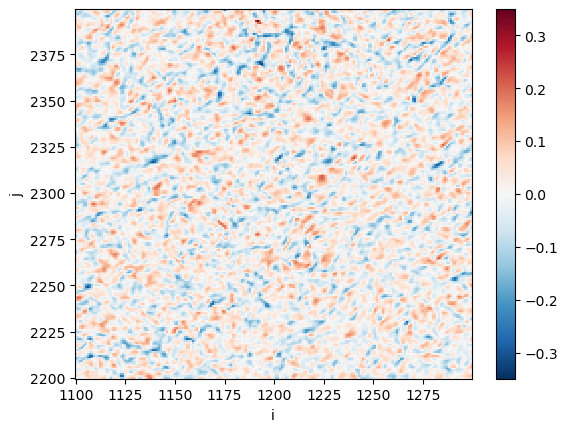

In [14]:
div.isel(i=slice(0,200)).isel(j=slice(0,200)).plot()